# **Predicción de Ventas y Análisis de Factores Claves en un Entorno Retail**

## **Abstracto**

En el contexto de un negocio retail, la correcta **estimación de la demanda resulta fundamental para la toma de decisiones comerciales**, tales como la planificación de promociones, la gestión de inventarios y la definición de estrategias de precios.

El presente trabajo tiene como objetivo analizar el comportamiento de las ventas y desarrollar un modelo predictivo que permita anticipar la demanda futura. Este análisis está **orientado a responsables comerciales, analistas de negocio y tomadores de decisiones** que buscan mejorar la eficiencia operativa y la rentabilidad del negocio.

Desde el punto de vista analítico, el problema se aborda como una **tarea de regresión**, utilizando **modelos de Machine Learning** y **técnicas de ingeniería de atributos** que incorporan tanto variables temporales como información del comportamiento histórico de las ventas. De esta manera, se busca no solo generar predicciones, sino también comprender los factores que influyen en la evolución de la demanda.

## **Problema a resolver**

El objetivo principal de este trabajo es **predecir el nivel de ventas** a partir de información histórica y variables explicativas asociadas al comportamiento del negocio.

Desde el punto de vista analítico, este problema se encuadra como un **problema de regresión**, dado que la **variable objetivo (ventas) es continua y se busca estimar su valor en función de distintas variables independientes.**

A través del uso de modelos de Machine Learning, se intentará identificar patrones en los datos que permitan anticipar la demanda futura, aportando información relevante para la toma de decisiones comerciales.

En particular, se busca evaluar **en qué medida variables como promociones, estacionalidad y comportamiento histórico influyen en la evolución de las ventas.**

In [29]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## **Carga de datos**

Se carga el dataset que contiene información de ventas junto con variables asociadas al negocio, como promociones, tienda y categoría de productos.

Estos datos serán utilizados para analizar el comportamiento de la demanda y construir modelos predictivos.

In [30]:
url = "https://raw.githubusercontent.com/santiagoq21/proyecto-final-datascience-II---Santiago_Quagliotti/refs/heads/main/train_filtrado.csv"

df = pd.read_csv(url)
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,12,2013-01-01,1,GROCERY I,0.0,0
1,1794,2013-01-02,1,GROCERY I,2652.0,0
2,3576,2013-01-03,1,GROCERY I,2121.0,0
3,5358,2013-01-04,1,GROCERY I,2056.0,0
4,7140,2013-01-05,1,GROCERY I,2216.0,0


Para simplificar el análisis y facilitar la interpretación de los resultados, se trabaja con una tienda y una categoría específica de productos. Debido al peso del archivo original, el cual Github, no permitia subirlo, opte por filtrar el negocio y familia de producto sobre el cual desarrolle el trabajo, y subir ese dataset filtrado.

## **Análisis Exploratorio de Datos (EDA)**

En este apartado realizo un análisis exploratorio de los datos para poder comprender su estructura, identificar posibles problemas de calidad y detectar patrones relevantes en el comportamiento de las ventas.

In [31]:
# Análisis de Datos
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1684 entries, 0 to 1683
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1684 non-null   int64  
 1   date         1684 non-null   object 
 2   store_nbr    1684 non-null   int64  
 3   family       1684 non-null   object 
 4   sales        1684 non-null   float64
 5   onpromotion  1684 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 79.1+ KB


,id,store_nbr,sales,onpromotion
count,1.684000e+03,1684.0,1684.000000,1684.000000
mean,1.499565e+06,1.0,2223.172803,17.560570
std,8.665389e+05,0.0,779.285352,24.741069
min,1.200000e+01,1.0,0.000000,0.000000
25%,7.497885e+05,1.0,1873.500000,0.000000
50%,1.499565e+06,1.0,2283.500000,6.000000
75%,2.249342e+06,1.0,2649.000000,28.000000
max,2.999118e+06,1.0,9065.000000,167.000000


Se observa que el dataset contiene información de ventas junto con variables explicativas como promociones, tienda y categoría de producto.

Las variables presentan tipos de datos adecuados para el análisis y no se identifican inconsistencias relevantes.

In [32]:
# Valores Faltantes
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


No se observan valores faltantes, en ninguna de las variables.

In [33]:
# Conversión de Fechas
df["date"] = pd.to_datetime(df["date"])

Se transforma la variable de fecha (estaba en formato string) a formato datetime para facilitar el análisis temporal y la generación de nuevas variables.

In [34]:
# Variables de Calendario
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

Se crean nuevas variales a partir de la fecha (year, month y dayofweek), de esta manera el modelo va a poder detectar patrones anuales, mensuales y diarios.

# **Ventas en el tiempo**

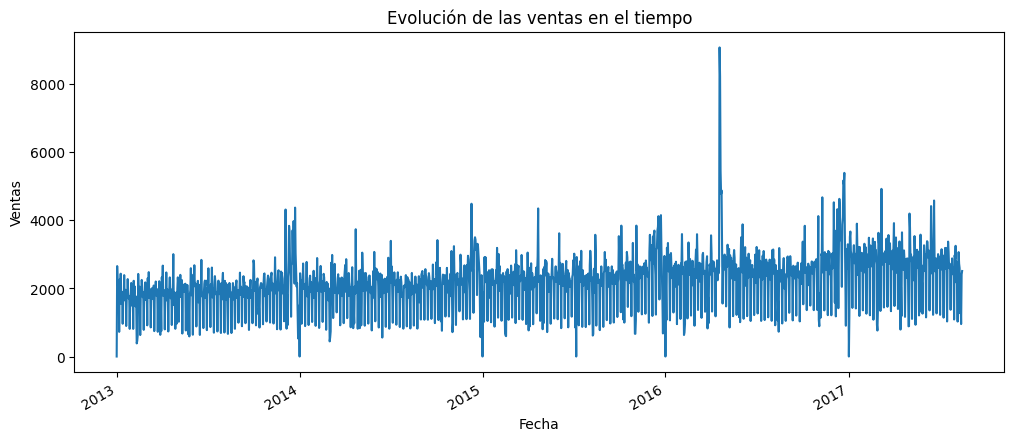

In [35]:
df.groupby("date")["sales"].sum().plot(figsize=(12,5))
plt.title("Evolución de las ventas en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

Se observa la evolución de las ventas a lo largo del tiempo, donde pueden identificarse fluctuaciones que sugieren la presencia de patrones de tendencia y estacionalidad.

#**Ventas por mes**

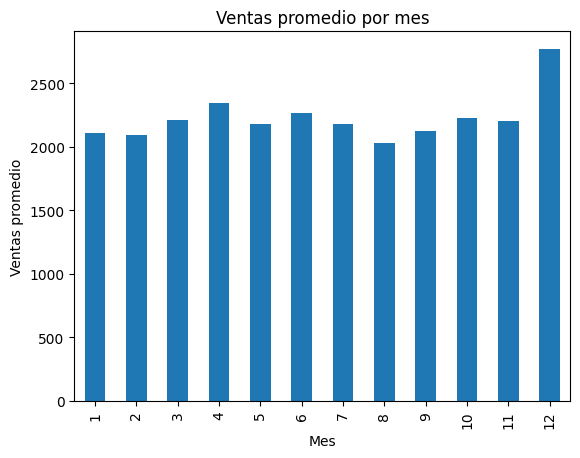

In [36]:
df.groupby("month")["sales"].mean().plot(kind="bar")
plt.title("Ventas promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas promedio")
plt.show()

El análisis mensual permite identificar variaciones en el nivel de ventas, lo que sugiere la existencia de estacionalidad en la demanda. Se observa un incremento significativo en diciembre.

#**Ventas por día de la semana**

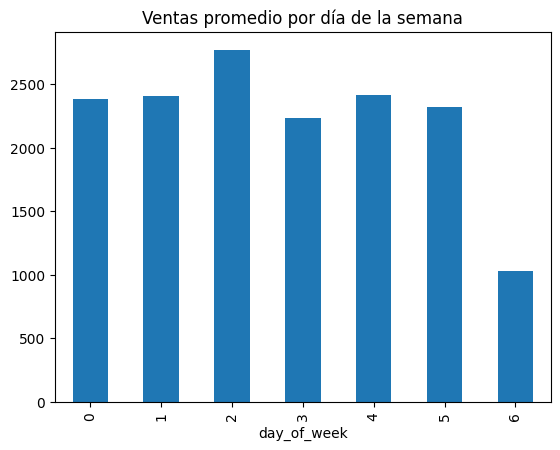

In [37]:
df.groupby("day_of_week")["sales"].mean().plot(kind="bar")
plt.title("Ventas promedio por día de la semana")
plt.show()

Se observan que las ventas dependen del día de la semana.

0 = lunes  
1 = martes  
2 = miércoles  
3 = jueves  
4 = viernes  
5 = sábado  
6 = domingo  

#**Boxplot de ventas**



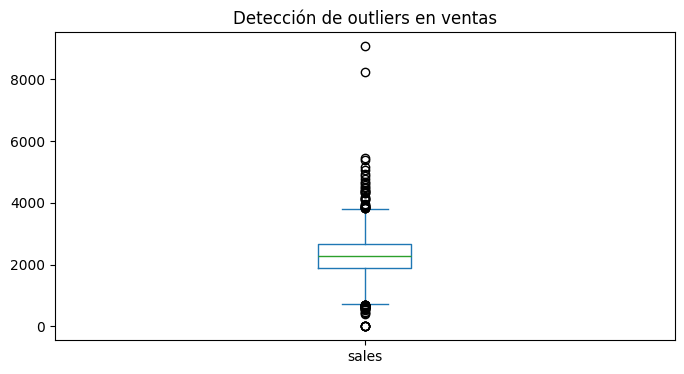

In [38]:
df["sales"].plot(kind="box", figsize=(8,4))
plt.title("Detección de outliers en ventas")
plt.show()

El análisis mediante boxplot evidencia la presencia de valores atípicos en la variable de ventas, tanto por encima como por debajo del rango habitual.
Estos valores extremos son esperables en contextos comerciales, donde pueden existir picos de demanda asociados a promociones o eventos específicos.
Por este motivo, no se eliminan del dataset, ya que contienen información relevante que puede mejorar la capacidad predictiva del modelo.

#**Promociones**

In [39]:
df.groupby("onpromotion")["sales"].mean()

,sales
onpromotion,
0,1873.156794
1,1816.851852
2,1968.901961
3,2055.873239
4,2157.275862
...,...
118,3872.000000
123,4080.000000
125,5386.000000


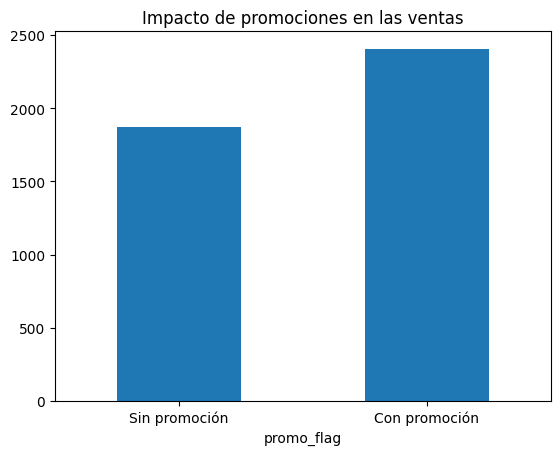

In [40]:
df["promo_flag"] = (df["onpromotion"] > 0).astype(int)

df.groupby("promo_flag")["sales"].mean().plot(kind="bar")
plt.title("Impacto de promociones en las ventas")
plt.xticks([0,1], ["Sin promoción", "Con promoción"], rotation=0)
plt.show()

Se crea una **variable sintética binaria (`promo_flag`)** que indica la presencia de promociones, con el objetivo de facilitar el análisis del impacto de las mismas en las ventas.

Esta variable será reutilizada en la etapa de modelado.

**Las ventas promedio son mayores cuando existen promociones activas, lo que evidencia su impacto positivo en la demanda.**

## **Conclusiones del análisis exploratorio**

A partir del análisis exploratorio, se identificaron patrones relevantes en el comportamiento de las ventas.

Se **observa la presencia de tendencias y estacionalidad, así como diferencias en función del día de la semana.**

Asimismo, las **promociones muestran un impacto positivo en el nivel de ventas, lo que las posiciona como un factor clave en la dinámica de la demanda.**

Estos hallazgos justifican la incorporación de variables temporales y de comportamiento histórico en la etapa de modelado.

## **Ingeniería de atributos**

## **Contexto**

En esta etapa **se generan nuevas variables a partir de la información original con el objetivo de mejorar la capacidad predictiva de los modelos.**

Se incorporan variables temporales y variables basadas en el comportamiento histórico de las ventas, fundamentales en problemas de series temporales.

**LAG FEATURES**

In [41]:
df = df.sort_values("date")

df["sales_lag1"] = df["sales"].shift(1)
df["sales_lag7"] = df["sales"].shift(7)

Incorporo ventas del pasado para que el modelo no mire solo el día actual, sino también cómo viene la demanda, captando patrones que se repiten en la semana.

**PROMEDIOS MÓVILES**

In [42]:
df["rolling_mean_7"] = df["sales"].rolling(window=7).mean()

Se agrega un promedio de los últimos 7 días para que el modelo no dependa de un solo día, sino que tenga en cuenta cómo viene la demanda en la última semana.

**VARIABLE EXTRA**

In [43]:
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

Se crea una variable que indica si el día es fin de semana o no, para que el modelo pueda diferenciar el comportamiento de las ventas entre días laborales y fines de semana.

Si es sábado o domingo → 1
Si es lunes a viernes → 0

**LIMPIEZA FINAL**

In [44]:
df = df.dropna()

Se eliminan los valores nulos generados por las variables de rezago y promedios móviles.

## **Entrenamiento de modelos**

In [45]:
features = [
    "promo_flag",
    "year",
    "month",
    "day_of_week",
    "is_weekend",
    "sales_lag1",
    "sales_lag7",
    "rolling_mean_7"
]

X = df[features]
y = df["sales"]

Se seleccionan como variables predictoras aquellas relacionadas con promociones, factores temporales y comportamiento histórico de las ventas.
En particular, se incluyen variables de calendario, una variable indicadora de promociones y variables de rezago y tendencia, con el objetivo de capturar patrones temporales y mejorar la capacidad predictiva del modelo.

**TRAIN / TEST (SERIES TEMPORALES)**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False
)

Se divide el dataset en entrenamiento y prueba respetando el orden de los datos en el tiempo, evitando mezclar información futura en el entrenamiento del modelo.

**MODELO 1 — REGRESIÓN LINEAL**

In [47]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

Se entrena un modelo de Regresión Lineal aplicando previamente una estandarización de las variables mediante un Pipeline. Esto permite trabajar con variables en la misma escala y mejorar la estabilidad del modelo.

**MODELO 2 — RANDOM FOREST**

In [48]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

Se utiliza Random Forest, un modelo basado en múltiples árboles de decisión, que permite capturar relaciones más complejas entre las variables y mejorar la capacidad de predicción respecto a modelos más simples como la regresión lineal.

**MÉTRICAS**

In [49]:
# Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Linear Regression - MAE:", mae_lr)
print("Linear Regression - RMSE:", rmse_lr)

print("Random Forest - MAE:", mae_rf)
print("Random Forest - RMSE:", rmse_rf)

Linear Regression - MAE: 424.4738818168647
Linear Regression - RMSE: 577.3609068215433
Random Forest - MAE: 309.2126666666667
Random Forest - RMSE: 495.8763731021598


Al comparar ambos modelos, se observa que Random Forest presenta menores valores de MAE y RMSE en relación a la Regresión Lineal, lo que indica un mejor desempeño predictivo.
Esto sugiere que las relaciones entre las variables no son estrictamente lineales, y que un modelo más flexible permite capturar mejor los patrones presentes en los datos.

### **Validación cruzada de los modelos**

Para evaluar la robustez de los modelos en un contexto temporal, se utiliza `TimeSeriesSplit`, evitando mezclar datos futuros con pasados. Se calcula el MAE promedio por validación cruzada para comparar el desempeño de ambos modelos.

In [50]:
tscv = TimeSeriesSplit(n_splits=5)

scores_lr = cross_val_score(
    lr_model, X, y,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

scores_rf = cross_val_score(
    rf_model, X, y,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

print("MAE promedio CV Linear Regression:", -scores_lr.mean())
print("MAE promedio CV Random Forest:", -scores_rf.mean())

MAE promedio CV Linear Regression: 383.96488222575806
MAE promedio CV Random Forest: 305.7192114695341


Se aplica validación cruzada utilizando TimeSeriesSplit para evaluar la estabilidad de los modelos en el tiempo, evitando mezclar información futura con pasada.
Los resultados muestran que Random Forest mantiene un menor error promedio en comparación con la Regresión Lineal, confirmando su mejor desempeño y mayor robustez.

**OPTIMIZACIÓN**

### **Optimización de hiperparámetros**

Se aplica `GridSearchCV` sobre Random Forest para encontrar la mejor combinación de hiperparámetros. La métrica utilizada para optimizar es el error absoluto medio (MAE), junto con validación cruzada temporal.

In [51]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error"
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

Mejores parámetros: {'max_depth': 5, 'n_estimators': 50}


### **Evaluación del modelo optimizado**

In [52]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Random Forest Optimizado - MAE:", mae_best)
print("Random Forest Optimizado - RMSE:", rmse_best)

Random Forest Optimizado - MAE: 314.61169468111643
Random Forest Optimizado - RMSE: 505.55700193576416


Se aplica GridSearchCV para optimizar los hiperparámetros del modelo Random Forest, evaluando distintas combinaciones de cantidad de árboles y profundidad máxima.
La mejor combinación encontrada fue max_depth = 5 y n_estimators = 50.
Si bien el modelo optimizado mantiene un buen desempeño, en el conjunto de prueba el Random Forest base obtuvo métricas levemente mejores, por lo que se conserva como referencia principal para la comparación final.

### **Comparación final de modelos**

A continuación se comparan los modelos entrenados utilizando MAE y RMSE sobre el conjunto de prueba. Esto permite seleccionar el modelo final con mejor desempeño predictivo.

In [53]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Linear",
        "Random Forest",
        "Random Forest Optimizado"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_best
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_best
    ]
})
print("Comparación final de modelos")
resultados


Comparación final de modelos


,Modelo,MAE,RMSE
0,Regresión Linear,424.473882,577.360907
1,Random Forest,309.212667,495.876373
2,Random Forest Optimizado,314.611695,505.557002


A partir de la comparación de los modelos utilizando las métricas MAE y RMSE, se observa que el modelo de Random Forest presenta el mejor desempeño predictivo.

Tanto en error promedio como en la penalización de errores grandes, este modelo supera a la Regresión Lineal y al Random Forest optimizado.

Si bien se realizó una optimización de hiperparámetros mediante GridSearchCV, el modelo base obtuvo resultados levemente superiores en el conjunto de prueba, por lo que se selecciona como modelo final.

Esto sugiere que las relaciones presentes en los datos no son estrictamente lineales y que modelos más flexibles como Random Forest logran capturar mejor los patrones de la demanda.

### **Importancia de variables en el modelo final**

Se analiza la importancia relativa de cada variable en el modelo Random Forest optimizado, con el objetivo de comprender qué factores influyen en la predicción de las ventas.

In [54]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": best_model.feature_importances_
})

importancias = importancias.sort_values(by="Importancia", ascending=False)

importancias

,Variable,Importancia
3,day_of_week,0.529736
7,rolling_mean_7,0.340053
5,sales_lag1,0.074785
6,sales_lag7,0.045761
1,year,0.004959
2,month,0.002946
4,is_weekend,0.000990
0,promo_flag,0.000769


El análisis de importancia de variables muestra que el día de la semana y la tendencia reciente de ventas son los factores más relevantes para la predicción.
Esto indica que el comportamiento temporal de la demanda tiene mayor peso que otras variables como las promociones.

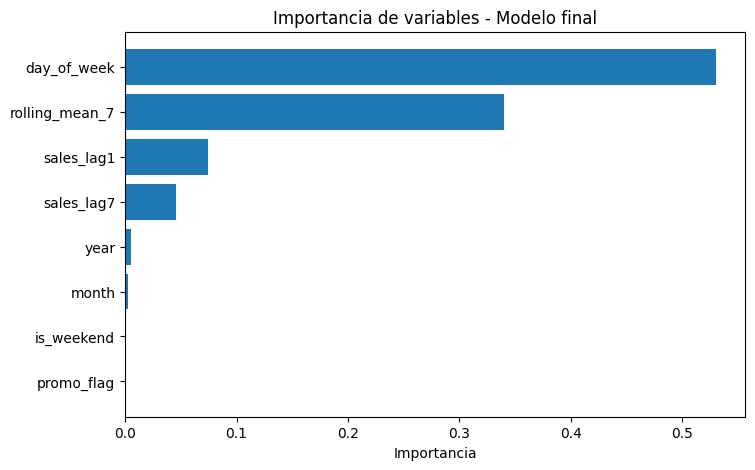

In [55]:
plt.figure(figsize=(8,5))
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables - Modelo final")
plt.xlabel("Importancia")
plt.show()

**VISUALIZACIÓN FINAL**

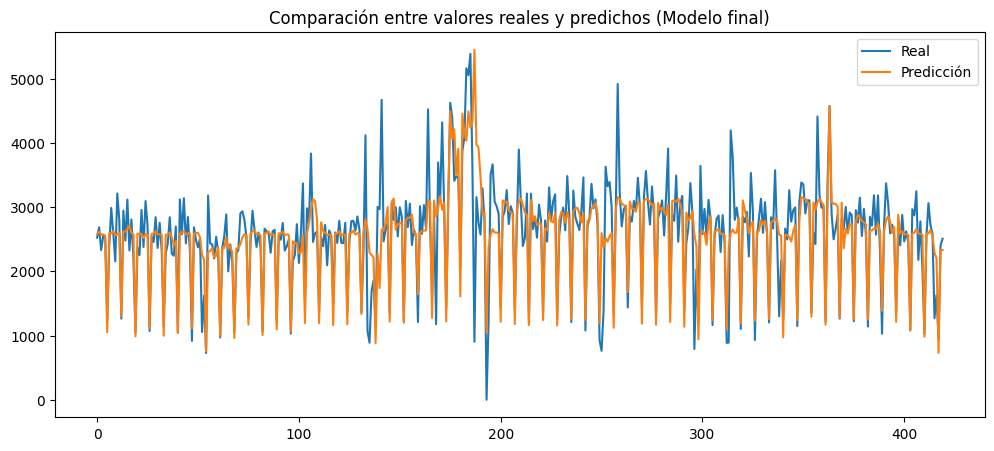

In [56]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Real")
plt.plot(y_pred_best, label="Predicción")
plt.legend()
plt.title("Comparación entre valores reales y predichos (Modelo final)")
plt.show()

El modelo logra capturar adecuadamente la tendencia general de las ventas, mostrando un buen ajuste entre valores reales y predichos.
Sin embargo, se observan diferencias en los valores extremos, donde el modelo tiende a suavizar los picos de demanda.

**Selección de modelo**

A partir de la comparación de métricas (MAE y RMSE) y los resultados de la validación cruzada, se selecciona como modelo final el Random Forest base.

Este modelo presenta el menor error de predicción en comparación con la Regresión Lineal y el Random Forest optimizado, lo que indica una mejor precisión en la estimación de las ventas.

Si bien se realizó una optimización de hiperparámetros mediante GridSearchCV, esta no logró mejorar el desempeño del modelo base, por lo que se opta por mantener la versión original.

Además, la validación cruzada confirma su estabilidad en el tiempo, lo que lo convierte en la mejor opción para la predicción en este contexto.

**Conclusión final**

El problema fue abordado como uno de regresión, con el objetivo de predecir el nivel de ventas a partir de variables temporales, promociones y comportamiento histórico.

Se entrenaron dos modelos de Machine Learning:

Regresión Lineal (con estandarización)
Random Forest

Ambos modelos fueron evaluados mediante métricas de error (MAE y RMSE), validación cruzada temporal utilizando TimeSeriesSplit y optimización de hiperparámetros mediante GridSearchCV.

De acuerdo con los resultados obtenidos, el modelo seleccionado fue Random Forest, ya que presentó el menor error de predicción y una mayor capacidad para capturar relaciones no lineales entre las variables.

Esto sugiere que la dinámica de las ventas no responde a un comportamiento puramente lineal, sino que depende de múltiples factores combinados como estacionalidad, promociones y comportamiento pasado.

La optimización de hiperparámetros no logró mejorar el rendimiento del modelo, lo cual indica que la configuración base ya resultaba adecuada para este problema.

**Interpretación de resultados y aplicación en el negocio**

El análisis de importancia de variables permite identificar los factores clave que influyen en la predicción de las ventas.

Se observa que las variables relacionadas con el comportamiento histórico (lags y promedios móviles) tienen mayor peso en el modelo, lo que indica una fuerte dependencia temporal en la demanda.

Asimismo, el día de la semana resulta ser una de las variables más relevantes, confirmando la existencia de patrones de consumo semanales.

Por otro lado, las promociones también impactan en las ventas, aunque en menor medida, lo que sugiere que deben utilizarse de forma estratégica y no como único mecanismo para impulsar la demanda.